In [17]:
import os
from langchain.chat_models import init_chat_model

llm=init_chat_model("groq:llama-3.3-70b-versatile")
llm

ChatGroq(output_version=None, profile={'max_input_tokens': 131072, 'max_output_tokens': 32768, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True}, client=<groq.resources.chat.completions.Completions object at 0x000002228FED8750>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x000002228FD5F410>, model_name='llama-3.3-70b-versatile', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None)

In [18]:
from typing import Annotated

from langchain_tavily import TavilySearch
from langchain_core.tools import tool
from typing_extensions import TypedDict

from langgraph.checkpoint.memory import MemorySaver
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode,tools_condition

from langgraph.types import Command,interrupt

In [19]:
class State(TypedDict):
    messages:Annotated[list,add_messages]

In [20]:
graph_builder=StateGraph(State)

In [21]:
@tool
def human_assistance(query:str)->str:
    """request assistance from a human"""
    human_response=interrupt({"query":query})
    return human_response["data"]

In [22]:
tool = TavilySearch(max_results=2)
tools=[tool,human_assistance]
llm_with_tools=llm.bind_tools(tools)

def chatbot(state:State):
    message=llm_with_tools.invoke(state["messages"])
    return {"messages":[message]}



In [23]:
graph_builder.add_node("chatbot",chatbot)

tool_node=ToolNode(tools=tools)
graph_builder.add_node("tools",tool_node)

graph_builder.add_conditional_edges("chatbot",tools_condition)

graph_builder.add_edge(START,"chatbot")
graph_builder.add_edge("chatbot",END)

memory=MemorySaver()

graph=graph_builder.compile(checkpointer=memory)


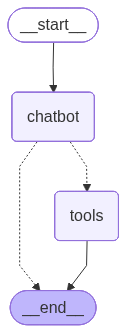

In [24]:
graph

In [30]:
user_input="I need some expert guidance and assistance for building an AI agent. Could you request assistance for me?"
config = {"configurable": {"thread_id": "1"}}

events=graph.stream({
    "messages":user_input},
    config,
    stream_mode="values"
    
    )

for event in events:
    if "messages" in event:
        event["messages"][-1].pretty_print()

================================ Human Message =================================

I need some expert guidance and assistance for building an AI agent. Could you request assistance for me?
================================== Ai Message ==================================
Tool Calls:
  human_assistance (e3r76ecq9)
 Call ID: e3r76ecq9
  Args:
    query: building an AI agent, need expert guidance and assistance
================================== Ai Message ==================================
Tool Calls:
  human_assistance (e3r76ecq9)
 Call ID: e3r76ecq9
  Args:
    query: building an AI agent, need expert guidance and assistance


In [31]:
human_reponse=(
    "We, the experts are here to help! We'd recommend you check out LangGraph to build your agent."
    " It's much more reliable and extensible than simple autonomous agents."
)

human_command=Command(resume ={"data":human_reponse})

events=graph.stream(human_command,config,stream_mode="values")

for event in events:
    if "messages" in event:
        event["messages"][-1].pretty_print()

================================== Ai Message ==================================
Tool Calls:
  human_assistance (e3r76ecq9)
 Call ID: e3r76ecq9
  Args:
    query: building an AI agent, need expert guidance and assistance
================================= Tool Message =================================
Name: human_assistance

We, the experts are here to help! We'd recommend you check out LangGraph to build your agent. It's much more reliable and extensible than simple autonomous agents.
